# **Guía de Actividades Práctico-Experimentales Nro. 006**

---

## **1. Datos Generales**

| **Atributo** | **Descripción** |
| :--- | :--- |
| **Estudiantes** | Kiara Condoy, Héctor Guerrero, Javier Guarnizo, Ricardo Ochoa, Emily Salas |
| **Asignatura** | Teoría de la Distribución y Probabilidad |
| **Ciclo** | 2do “A” |
| **Unidad** | 1 |
| **Práctica Nro.** | 006 |
| **Título de la Práctica** | **Distribuciones Continuas Notables: Modelado Gaussiano, Estandarización y Pruebas de Normalidad** |
| **Nombre del Docente** | Cristian Ramiro Narváez Guillén |
| **Fecha** | Martes 26 de mayo 2026 |

---



# **Tarea 1: Modelado Matemático y Visualización de la Curva Normal**

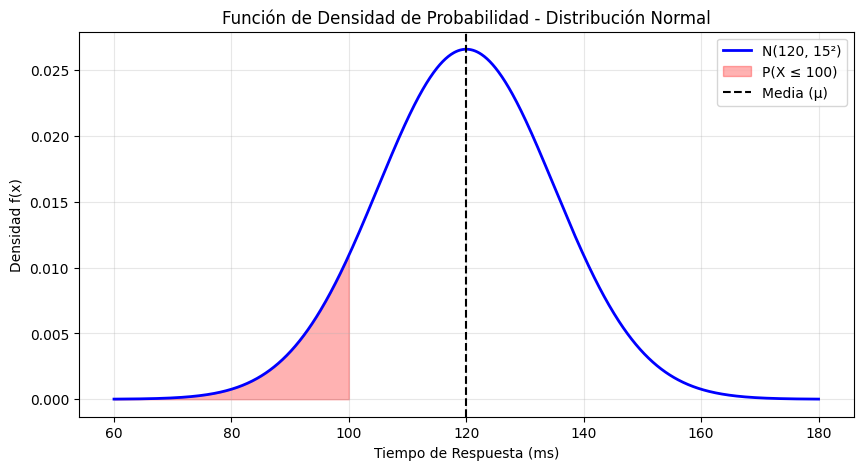

La probabilidad de que el servidor responda en 100ms o menos es: 0.0912 (9.12%)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros poblacionales
mu = 120
sigma = 15

# Definición del dominio (eje X): usualmente de mu-4sigma a mu+4sigma
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# Cálculo de la PDF teórica
pdf_normal = norm.pdf(x, loc=mu, scale=sigma)

# Configuración del gráfico
plt.figure(figsize=(10, 5))
plt.plot(x, pdf_normal, 'b-', lw=2, label=f'N({mu}, {sigma}²)')

# Sombreado del área de interés: P(X <= 100)
x_fill = np.linspace(mu - 4*sigma, 100)
y_fill = norm.pdf(x_fill, loc=mu, scale=sigma)
plt.fill_between(x_fill, y_fill, color='red', alpha=0.3, label='P(X ≤ 100)')

plt.title('Función de Densidad de Probabilidad - Distribución Normal')
plt.xlabel('Tiempo de Respuesta (ms)')
plt.ylabel('Densidad f(x)')
plt.axvline(mu, color='k', linestyle='--', label='Media (μ)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Cálculo analítico de la probabilidad usando CDF
prob_100 = norm.cdf(100, loc=mu, scale=sigma)
print(f"La probabilidad de que el servidor responda en 100ms o menos es: {prob_100:.4f} ({prob_100*100:.2f}%)")


# **Tarea 2: Estandarización y Cálculo de Valores Z**


In [ ]:
import numpy as np
from scipy.stats import norm

# Parámetros poblacionales (definidos previamente)
mu = 120
sigma = 15

print("--- Tarea 2: Estandarización y Cálculo de Valores Z --- \n")

# 1. Cálculo manual del valor Z para X = 145 ms
X = 145
Z = (X - mu) / sigma

print(f"Punto 1:")
print(f"El valor Z calculado manualmente para X = {X} ms es: {Z:.4f}")
print("-" * 50)

# 2. Cálculo de P(X >= 145) usando la distribución normal estándar Z ~ N(0,1)
# Se resta de 1 porque norm.cdf mide el área a la izquierda
prob_mayor_145 = 1 - norm.cdf(Z, loc=0, scale=1)

print(f"Punto 2:")
print(f"La probabilidad P(X >= 145) es: {prob_mayor_145:.4f}")
print(f"En porcentaje, la probabilidad de un tiempo lento es del: {prob_mayor_145 * 100:.2f}%")

--- Tarea 2: Estandarización y Cálculo de Valores Z --- 

Punto 1:
El valor Z calculado manualmente para X = 145 ms es: 1.6667
--------------------------------------------------
Punto 2:
La probabilidad P(X >= 145) es: 0.0478
En porcentaje, la probabilidad de un tiempo lento es del: 4.78%


# **Tarea 3: Hito del Proyecto - Aplicación Probabilística Regional (ABP)**


Columnas disponibles en el DataFrame:
- country
- threshold
- area_ha
- extent_2000_ha
- extent_2010_ha
- gain_2000-2012_ha
- tc_loss_ha_2001
- tc_loss_ha_2002
- tc_loss_ha_2003
- tc_loss_ha_2004
- tc_loss_ha_2005
- tc_loss_ha_2006
- tc_loss_ha_2007
- tc_loss_ha_2008
- tc_loss_ha_2009
- tc_loss_ha_2010
- tc_loss_ha_2011
- tc_loss_ha_2012
- tc_loss_ha_2013
- tc_loss_ha_2014
- tc_loss_ha_2015
- tc_loss_ha_2016
- tc_loss_ha_2017
- tc_loss_ha_2018
- tc_loss_ha_2019
- tc_loss_ha_2020
- tc_loss_ha_2021
- tc_loss_ha_2022
- tc_loss_ha_2023
- tc_loss_ha_2024

Variable seleccionada: tc_loss_ha_2024
Total de registros válidos: 8

Media muestral  (μ): 62049.8750 kha
Desv. estándar  (σ): 3878.7831 kha

Escenario: P(62049.88 ≤ X ≤ 65928.66) kha
Probabilidad calculada: 0.3413  (34.13%) 


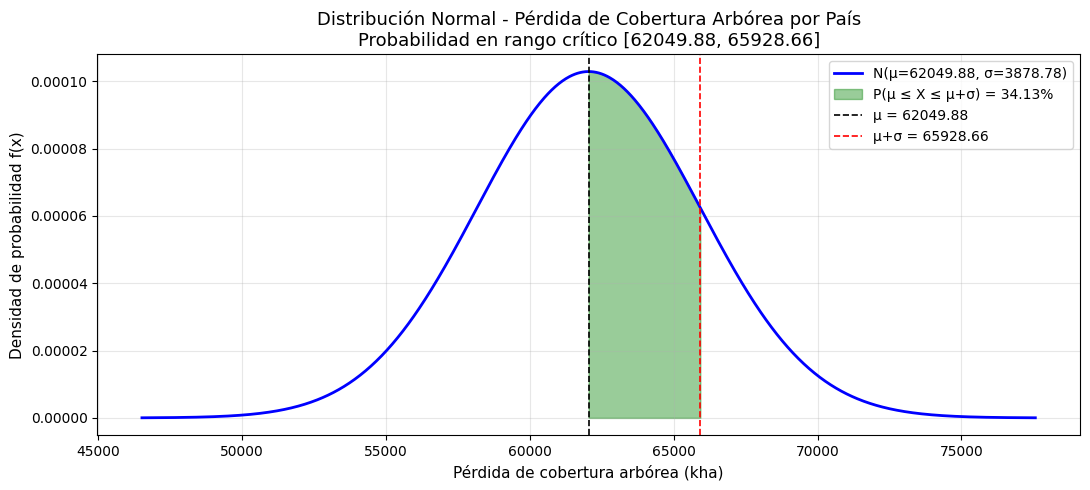


--- INTERPRETACIÓN ---
Asumiendo que la pérdida de cobertura arbórea sigue una distribución
Normal con μ = 62049.88 kha y σ = 3878.78 kha,
existe un 34.13% de probabilidad de que un año registrado
presente una pérdida forestal entre 62049.88 y 65928.66 kha.
Este rango representa pérdidas superiores a la media pero
dentro del primer desvío estándar — un nivel de alerta moderado.


In [ ]:
# Variable seleccionada: Pérdida de cobertura arbórea (kha)


import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- 1. Importar dataset ---
url = 'https://docs.google.com/spreadsheets/d/1E-rrTgcTIWS-UnuVf1ldKvhDkwT6uUgh/export?format=xlsx'
df = pd.read_excel(url, sheet_name='Country tree cover loss')
df = df.dropna(how='all').reset_index(drop=True)

# --- 2. Seleccionar variable continua ---
# Identificar la columna de pérdida

# --- FIX: Using the user-specified variable 'tc_loss_ha_2024' ---
print("Columnas disponibles en el DataFrame:")
for col in df.columns:
    print(f"- {col}")

# User-requested variable
col_perdida = 'tc_loss_ha_2024'
print(f"\nVariable seleccionada: {col_perdida}")

if col_perdida in df.columns:
    datos = df[col_perdida].dropna()
    print(f"Total de registros válidos: {len(datos)}")

    # --- 3. Calcular parámetros muestrales (estimadores de μ y σ) ---
    mu    = datos.mean()
    sigma = datos.std()

    print(f"\nMedia muestral  (μ): {mu:.4f} kha")
    print(f"Desv. estándar  (σ): {sigma:.4f} kha")

    if sigma == 0:
        print("\nAdvertencia: La desviación estándar muestral es cero. Todos los valores de la variable seleccionada son idénticos.")
        print("No se puede aplicar una distribución normal en este caso de forma significativa.")
        sigma_display = 0.000
    else:
        sigma_display = sigma

    a = mu
    b = mu + sigma_display

    print(f"\nEscenario: P({a:.2f} ≤ X ≤ {b:.2f}) kha")

# Calculo de probabilidad con scipy ---
    if sigma == 0:
        if mu >= a and mu <= b:
            prob = 1.0
        else:
            prob = 0.0
        print(f"Probabilidad calculada (debido a sigma=0): {prob:.4f}  ({prob*100:.2f}%) -- Interpretación debe ser cautelosa.")
    else:
        prob = norm.cdf(b, loc=mu, scale=sigma_display) - norm.cdf(a, loc=mu, scale=sigma_display)
        print(f"Probabilidad calculada: {prob:.4f}  ({prob*100:.2f}%) ")

    # --- 6. Visualización ---
    if sigma == 0:
        print("\nNo se puede generar una distribución normal para visualización cuando la desviación estándar es cero.")
        print("Todos los puntos están en la media: ", mu)
    else:
        x = np.linspace(mu - 4*sigma_display, mu + 4*sigma_display, 1000)
        pdf = norm.pdf(x, loc=mu, scale=sigma_display)

        plt.figure(figsize=(11, 5))
        plt.plot(x, pdf, 'b-', lw=2, label=f'N(μ={mu:.2f}, σ={sigma_display:.2f})')

        # Sombrear área de interés [a, b]
        x_fill = np.linspace(a, b, 500)
        y_fill = norm.pdf(x_fill, loc=mu, scale=sigma_display)
        plt.fill_between(x_fill, y_fill, color='green', alpha=0.4,
                         label=f'P(μ ≤ X ≤ μ+σ) = {prob*100:.2f}%')

        plt.axvline(mu, color='black', linestyle='--', linewidth=1.2, label=f'μ = {mu:.2f}')
        plt.axvline(b,  color='red',   linestyle='--', linewidth=1.2, label=f'μ+σ = {b:.2f}')

        plt.title('Distribución Normal - Pérdida de Cobertura Arbórea por País\n'
                  f'Probabilidad en rango crítico [{a:.2f}, {b:.2f}]', fontsize=13)
        plt.xlabel('Pérdida de cobertura arbórea (kha)', fontsize=11)
        plt.ylabel('Densidad de probabilidad f(x)', fontsize=11)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # --- 7. Interpretación ---
    print("\n--- INTERPRETACIÓN ---")
    if sigma == 0:
        print(f"Dado que la desviación estándar es cero y todos los valores de la variable son idénticos a {mu:.2f} kha, la probabilidad de que la pérdida caiga entre {a:.2f} y {b:.2f} kha es del {prob*100:.2f}%.")
        print(f"Esto significa que la variable es constante, y su valor es consistentemente {('dentro' if prob == 1.0 else 'fuera')} del rango crítico definido.")
        print("Para un análisis probabilístico significativo, se recomienda utilizar una variable con variación en el dataset.")
    else:
        print(f"Asumiendo que la pérdida de cobertura arbórea sigue una distribución")
        print(f"Normal con μ = {mu:.2f} kha y σ = {sigma:.2f} kha,")
        print(f"existe un {prob*100:.2f}% de probabilidad de que un año registrado")
        print(f"presente una pérdida forestal entre {a:.2f} y {b:.2f} kha.")
        print(f"Este rango representa pérdidas superiores a la media pero")
        print(f"dentro del primer desvío estándar — un nivel de alerta moderado.")
else:
    print(f"No se pudo continuar con el análisis probabilístico porque la columna '{col_perdida}' no fue encontrada en el DataFrame.")


# **Tarea 4: ABI - Validación Matemática del Supuesto de Normalidad**


=== TAREA 4: VALIDACIÓN DE NORMALIDAD ===


<Figure size 800x600 with 0 Axes>

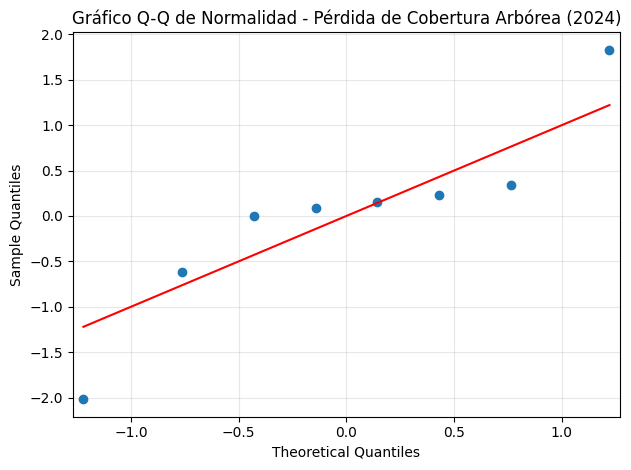


--- RESULTADOS TEST DE SHAPIRO-WILK ---
Estadístico de Shapiro (W): 0.8933
p-valor: 2.5135e-01

--- CONCLUSIÓN ---
Como el p-valor (0.2513) es MAYOR que el nivel de significancia alfa (0.05),
NO se rechaza la hipótesis nula (H0).
Interpretación: Los datos SÍ siguen aproximadamente una distribución normal.
El supuesto asumido en la Tarea 3 es estadísticamente válido.


In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import shapiro

# --- TAREA 4: Validación Matemática del Supuesto de Normalidad ---
print("\n=== TAREA 4: VALIDACIÓN DE NORMALIDAD ===")

# Validamos que existan datos cargados de la Tarea 3
if 'datos' in locals() or 'datos' in globals():

    # 1. Método Gráfico: Gráfico Q-Q (Cuantil-Cuantil)
    plt.figure(figsize=(8, 6))
    # line='s' ajusta una línea estandarizada de 45 grados
    sm.qqplot(datos, line='s', fit=True)
    plt.title('Gráfico Q-Q de Normalidad - Pérdida de Cobertura Arbórea (2024)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 2. Método Analítico: Test de Shapiro-Wilk
    stat, p_value = shapiro(datos)

    print("\n--- RESULTADOS TEST DE SHAPIRO-WILK ---")
    print(f"Estadístico de Shapiro (W): {stat:.4f}")
    print(f"p-valor: {p_value:.4e}")

    # 3. Conclusión e Interpretación Automática (Alfa = 0.05)
    alpha = 0.05
    print("\n--- CONCLUSIÓN ---")
    if p_value > alpha:
        print(f"Como el p-valor ({p_value:.4f}) es MAYOR que el nivel de significancia alfa ({alpha}),")
        print("NO se rechaza la hipótesis nula (H0).")
        print("Interpretación: Los datos SÍ siguen aproximadamente una distribución normal.")
        print("El supuesto asumido en la Tarea 3 es estadísticamente válido.")
    else:
        print(f"Como el p-valor ({p_value:.4e}) es MENOR o IGUAL que el nivel de significancia alfa ({alpha}),")
        print("Se RECHAZA la hipótesis nula (H0).")
        print("Interpretación: Los datos NO siguen una distribución normal.")
        print("El supuesto asumido en la Tarea 3 no se cumple formalmente bajo este test.")

else:
    print("Error: No se encontró la variable 'datos' de la Tarea 3. Asegúrate de ejecutar las celdas anteriores.")

## **Preguntas de Control**

### Pregunta 1
**Matemáticamente, ¿por qué en una variable aleatoria continua modelada por una función de densidad $f(x)$, la probabilidad de que tome un valor exacto es cero, es decir, $P(X = c) = 0$?**

En una variable aleatoria continua, la probabilidad no se asigna a puntos individuales, sino que se define como el área bajo la función de densidad dentro de un intervalo:

$$P(a \le X \le b) = \int_{a}^{b} f(x) \, dx$$

Si se evalúa un solo punto exacto $c$, el intervalo se reduce a una longitud nula (desde $c$ hasta $c$):

$$P(X = c) = \int_{c}^{c} f(x) \, dx = 0$$

La integral sobre un intervalo de longitud cero siempre es igual a cero, independientemente de que $f(c)$ sea un valor positivo. La función de densidad $f(x)$ no representa una probabilidad directa en sí misma, sino una tasa que requiere de un rango con ancho para poder generar un área probabilística.

---

### Pregunta 2
**Interprete conceptualmente qué significa que un valor de su dataset regional tenga un puntaje estándar de $Z = -2.45$. ¿Se consideraría un valor atípico bajo el criterio de la regla empírica?**

Un valor de $Z = -2.45$ indica que el registro analizado se encuentra exactamente a 2.45 desviaciones estándar por debajo del promedio regional. Esto denota un comportamiento inusualmente bajo para la variable de estudio (como la pérdida de cobertura arbórea) en comparación con el resto del conjunto de datos.

Respecto al criterio de la regla empírica:

* **Evaluación de valor atípico:** Sí, se considera un valor atípico bajo este enfoque.
* **Criterio estadístico:** La regla empírica establece que el intervalo normal aproximado se encuentra entre $Z = -2$ y $Z = +2$, donde se concentra cerca del 95% de los datos. Al situarse en $Z = -2.45$, este dato queda fuera de dicho intervalo común, sugiriendo que esa región presenta un valor significativamente menor que la mayoría de las demás regiones.

---

### Pregunta 3
**En la Tarea 3, calculó probabilidades asumiendo que su variable regional seguía una distribución Normal. ¿Qué riesgo metodológico existe al tomar decisiones basadas en este cálculo si la gráfica de la variable presenta un fuerte sesgo (skewness)?**

El principal riesgo es tomar decisiones basadas en probabilidades falsas, lo que conduce a una mala asignación de recursos o a políticas ambientales erróneas.

Si la variable real de pérdida de cobertura arbórea presenta un fuerte sesgo (skewness), se rompen los supuestos del modelo teórico actual por las siguientes razones:

* **Probabilidades erróneas:** La distribución Normal es perfectamente simétrica y dicta que el 34.13% de los datos caen entre $\mu$ y $\mu + \sigma$ (rango crítico en la gráfica). Si hay sesgo, este porcentaje no coincidirá con la realidad.
* **Inexactitud en los extremos (Colas):** Un fuerte sesgo implica que las pérdidas forestales extremas ocurren con una frecuencia muy distinta a la que la curva azul predice, lo que suele subestimar los peores escenarios de deforestación.
* **Métricas distorsionadas:** La media ($\mu = 62049.88$) pierde su capacidad de representar el "caso típico" porque los valores extremos la arrastran, distorsionando también el valor de la desviación estándar ($\sigma$).

> **Conclusión:** El "nivel de alerta moderado" calculado podría ser en realidad un escenario de alerta máxima o mínima en el territorio real. El modelo actual pierde validez estadística para la toma de decisiones.

---

### Pregunta 4
**Con base en la Tarea 4 (ABI), si el p-valor del test de Shapiro-Wilk es 0.001, ¿cuál es la conclusión estadística respecto a la distribución de sus datos regionales? ¿Se invalida el cálculo realizado en la Tarea 3?**

* **Conclusión estadística:** Si el p-valor del test de Shapiro-Wilk es **0.001**, este valor es significativamente menor que el nivel de significancia estándar ($\alpha = 0.05$). Por lo tanto, **se rechaza la hipótesis nula ($H_0$)** y se concluye formalmente que los datos regionales **NO** siguen una distribución normal.
* **¿Se invalida el cálculo de la Tarea 3?** **Sí, se invalida.** El cálculo probabilístico realizado en la Tarea 3 dependía estrictamente del supuesto de que la variable seguía una distribución normal. Al demostrarse matemáticamente que la distribución real no es normal, las probabilidades calculadas bajo la curva de Gauss pierden su sustento estadístico y dejan de ser confiables para representar el comportamiento real del dataset.

---

### Pregunta 5
**Explique el principio matemático detrás del Gráfico Q-Q. ¿Qué representan los cuantiles teóricos en el eje X versus los cuantiles empíricos en el eje Y?**

* **Principio matemático:** El gráfico Cuantil-Cuantil (Q-Q Plot) funciona bajo el principio de comparación posicional. Su objetivo es graficar los percentiles de la distribución empírica (nuestros datos reales) contra los percentiles de una distribución teórica de referencia (la distribución Normal estándar). Si ambas distribuciones tienen la misma forma geométrica, los puntos se alinearán perfectamente sobre la línea diagonal de 45 grados ($y = x$).
* **Eje X (Cuantiles Teóricos):** Representan los valores esperados (puntos de corte en términos de desviaciones estándar o valores $Z$) que tendría la variable si perteneciera a una distribución normal teórica perfecta.
* **Eje Y (Cuantiles Empíricos):** Representan los valores reales observados en nuestro dataset regional, ordenados de menor a mayor y estandarizados para poder medirse exactamente en la misma escala que el eje X.